Depth injection of oil for MPRI-2 simulations at Turn Point

In [2]:
import os
import xarray as xr
import numpy as np
import itertools
import pandas as pd
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ssam_groups as groups
import ssam_plot as splot
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
hex_colour = '#6DB48E'
hatches = ['oo', '///', 'xx', '++']

## Oil injection files

In [26]:
oil_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/')
oil_paths = sorted([p for p in oil_root.glob('MPRI2_Scenario_5b_*_10000_WSF.nc')]) 
oil_files = [xr.open_dataset(oil_scen,decode_cf=True) for oil_scen in oil_paths]

In [27]:
oil_paths

[PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/MPRI2_Scenario_5b_2019-01-20_10000_WSF.nc'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/MPRI2_Scenario_5b_2019-04-12_10000_WSF.nc'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/MPRI2_Scenario_5b_2019-07-03_10000_WSF.nc'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/MPRI2_Scenario_5b_2019-10-20_10000_WSF.nc'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/MPRI2_Scenario_5b_2020-01-24_10000_WSF.nc'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/MPRI2_Scenario_5b_2020-04-11_10000_WSF.nc'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/MP

In [11]:
# Reading in Atlantis map
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
data_df_original = data_df_original.sort_values(by=['BOX_ID'])
data_df = data_df_original.set_index('BOX_ID')
box_depth = data_df['BOTZ']
land_boxes = box_depth==0
land_boxes = data_df.index[land_boxes]
land_df = data_df.loc[land_boxes]
jdf_df = data_df.loc[data_df.Region=='Juan de Fuca']
hs_df = data_df.loc[data_df.Region=='Howe Sound']
strait_df = data_df.loc[data_df.Region=='Strait of Georgia']
ps_df = data_df.loc[data_df.Region=='Puget Sound']

### Map PAH injection extent

low Fraser winter BOX_ID
4     446328916
8     485601055
9     288060859
33    181216243
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.01478557)
low Fraser spring BOX_ID
33    181216243
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.02296347)
low Fraser summer BOX_ID
33    181216243
37     61024272
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.0152791)
low Fraser fall BOX_ID
5     261808665
9     288060859
33    181216243
37     61024272
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.02470193)
high Fraser winter BOX_ID
8     485601055
33    181216243
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.03487215)
high Fraser spring BOX_ID
1     655575973
4     446328916
5     261808665
9     288060859
33    181216243
37     61024272
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.02114676)
high Fraser summer BOX_ID
33    181216243
36     95901178
37     61

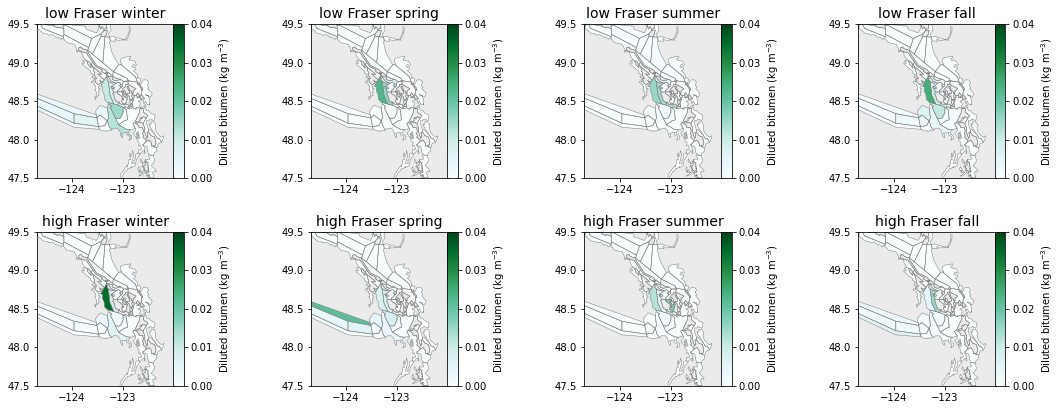

In [28]:
v_max = 0.04
fig = plt.figure(figsize=(18, 7), facecolor='white') #figsize=(9, 12)
gs = plt.GridSpec(2, 4, wspace=0.5, hspace=0.2, height_ratios=[1,1],)

position1 = 0
position2 = 0
for file, oil_path in zip(oil_files[0:4], oil_paths[0:4]):
    
    date = str(oil_path).split(sep = '_')[3]

    label = str(groups.conditions[date])
    oil_tb = file.variables['TPAH']
    oil_b = oil_tb.mean(axis=0)

    # Add scenario data to Atlantis spatial data
    data_df['TPAH'] = oil_b
    data_df.loc[land_boxes, 'TPAH'] = 0
    oil_df = data_df.loc[data_df['TPAH'] > 0.005] #5% of maximum
    print(label, oil_df.AREA, oil_b.max())

    ax = fig.add_subplot(gs[0, position1], facecolor = '#EBEBEB')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=-0.5)
    ax = data_df.plot(column = 'TPAH', ax=ax, cax=cax,cmap=cm.BuGn, legend_kwds={'label': 'Diluted bitumen (kg m$^{-3}$)'}, vmax=v_max,
    #ax = data_df.plot(column = 'BOTZ', ax=ax, cax=cax,cmap=cm.Blues, legend_kwds={'label': 'depth (m)'},
    legend=True, 
    )
    ax.set_title(label, fontsize = 14)
    ax.set_xlim(-124.7)
    ax.set_ylim(47.5, 49.5)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')
    #oil_df.plot(ax=ax, color='red',linewidths=0.5)
    position1 = position1+1

for file, oil_path in zip(oil_files[4:8], oil_paths[4:8]):

    date = str(oil_path).split(sep = '_')[3]

    label = str(groups.conditions[date])
    oil_tb = file.variables['TPAH']
    oil_b = oil_tb.mean(axis=0)

    # Add scenario data to Atlantis spatial data
    data_df['TPAH'] = oil_b
    data_df.loc[land_boxes, 'TPAH'] = 0
    oil_df = data_df.loc[data_df['TPAH'] > 0.005] 
    print(label, oil_df.AREA, oil_b.max())

    ax = fig.add_subplot(gs[1, position2], facecolor = '#EBEBEB')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=-0.5)
    ax = data_df.plot(column = 'TPAH', ax=ax, cax=cax,cmap=cm.BuGn, legend_kwds={'label': 'Diluted bitumen (kg m$^{-3}$)'}, vmax=v_max,
    #ax = data_df.plot(column = 'BOTZ', ax=ax, cax=cax,cmap=cm.Blues, legend_kwds={'label': 'depth (m)'},
    legend=True, 
    )
    ax.set_title(label, fontsize = 14)
    ax.set_xlim(-124.7)
    ax.set_ylim(47.5, 49.5)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')
    #oil_df.plot(ax=ax, color='red',linewidths=0.5)
    position2 = position2+1


In [14]:
affected_boxes = [1, 3, 4, 5, 8, 9, 33, 36, 37, 60]

### Plot PC injection by layer

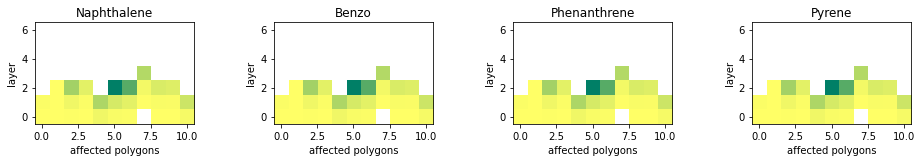

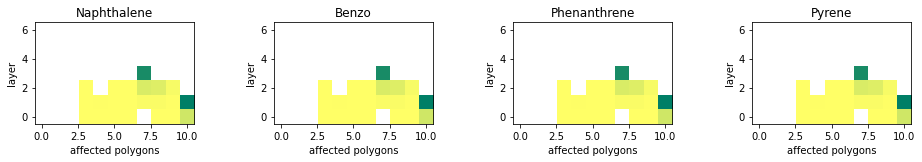

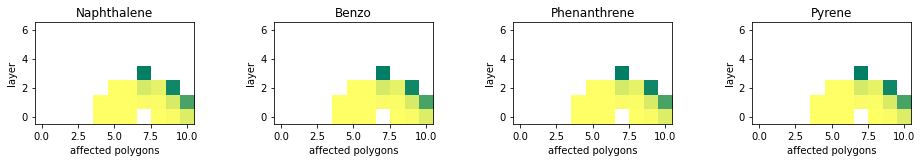

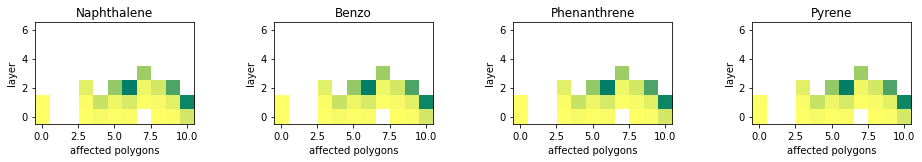

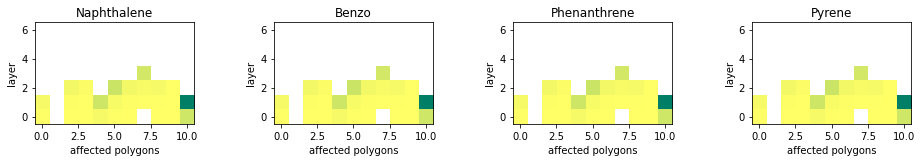

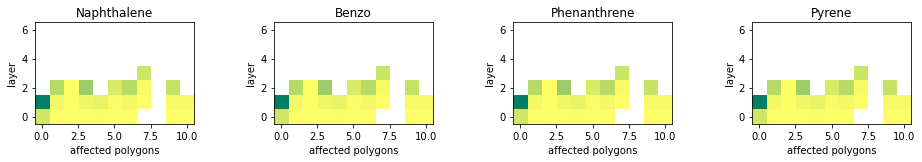

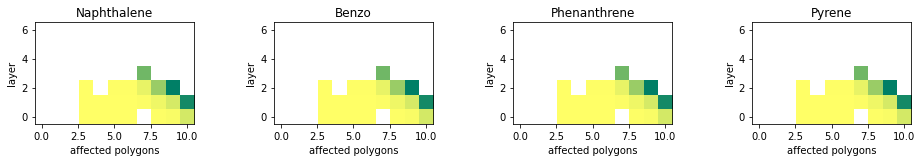

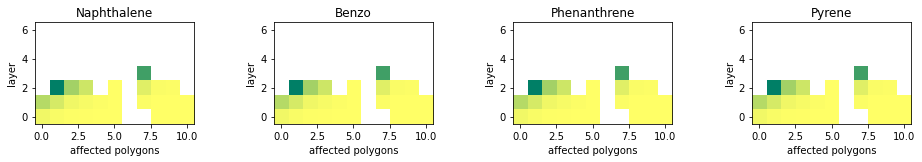

In [17]:
position = 0
for file in oil_files:
    fig = plt.figure(figsize=(20, 18), facecolor='white') #figsize=(9, 12)
    gs = plt.GridSpec(8, 5, wspace=0.5, hspace=0.2, height_ratios=[1,1,1,1,1,1,1,1],)
    for pah in groups.pahs:
        ax = fig.add_subplot(gs[position, list(groups.pahs).index(pah)])
        contam_bl = file.variables[str(pah)][8][affected_boxes][:]
        contam = contam_bl.transpose()
        ax.imshow(contam, cmap=cm.summer_r) #copper_r
        ax.invert_yaxis() 
        ax.set_title(str(pah), fontsize = 12)
        ax.set_ylabel('layer')
        ax.set_xlabel('affected polygons')
    position = position + 1

### With surface containment (e.g. booming) within 48 hours

In [30]:
oil_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/')
oil_paths = sorted([p for p in oil_root.glob('MPRI2_Scenario_5b_*_10000_WSF_contained.nc')]) 
oil_files = [xr.open_dataset(oil_scen,decode_cf=True) for oil_scen in oil_paths]

low Fraser winter BOX_ID
5     261808665
8     485601055
9     288060859
33    181216243
37     61024272
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.03333319)
low Fraser spring BOX_ID
33    181216243
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.045596)
low Fraser summer BOX_ID
9     288060859
33    181216243
37     61024272
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.03465204)
low Fraser fall BOX_ID
5     261808665
8     485601055
9     288060859
33    181216243
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.05278726)
high Fraser winter BOX_ID
33    181216243
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.05977051)
high Fraser spring BOX_ID
5     261808665
8     485601055
9     288060859
33    181216243
60    322474724
Name: AREA, dtype: int64 <xarray.Variable ()>
array(0.02958466)
high Fraser summer BOX_ID
9     288060859
33    181216243
36     95901178
37     610

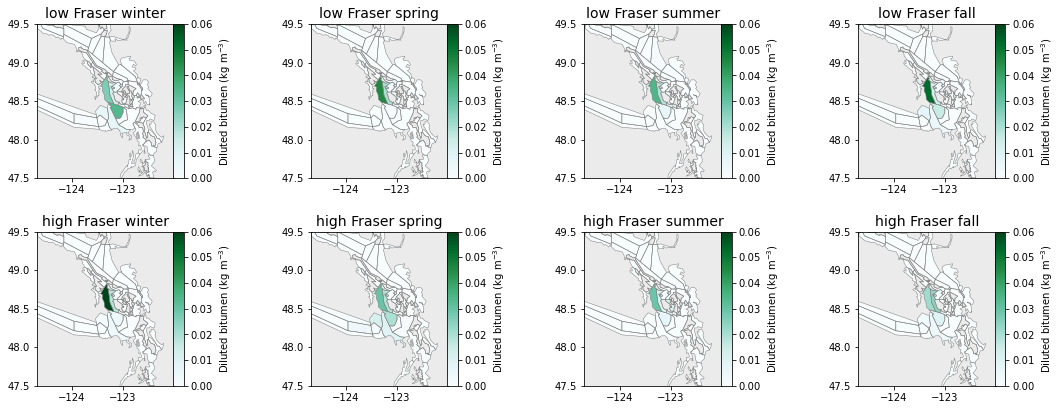

In [31]:
v_max = 0.06
fig = plt.figure(figsize=(18, 7), facecolor='white') #figsize=(9, 12)
gs = plt.GridSpec(2, 4, wspace=0.5, hspace=0.2, height_ratios=[1,1],)

position1 = 0
position2 = 0
for file, oil_path in zip(oil_files[0:4], oil_paths[0:4]):
    
    date = str(oil_path).split(sep = '_')[3]

    label = str(groups.conditions[date])
    oil_tb = file.variables['TPAH']
    oil_b = oil_tb.mean(axis=0)

    # Add scenario data to Atlantis spatial data
    data_df['TPAH'] = oil_b
    data_df.loc[land_boxes, 'TPAH'] = 0
    oil_df = data_df.loc[data_df['TPAH'] > 0.005] 
    print(label,oil_df.AREA,oil_b.max())

    ax = fig.add_subplot(gs[0, position1], facecolor = '#EBEBEB')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=-0.5)
    ax = data_df.plot(column = 'TPAH', ax=ax, cax=cax,cmap=cm.BuGn, legend_kwds={'label': 'Diluted bitumen (kg m$^{-3}$)'}, vmax=v_max,
    #ax = data_df.plot(column = 'BOTZ', ax=ax, cax=cax,cmap=cm.Blues, legend_kwds={'label': 'depth (m)'},
    legend=True, 
    )
    ax.set_title(label, fontsize = 14)
    ax.set_xlim(-124.7)
    ax.set_ylim(47.5, 49.5)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')
    #oil_df.plot(ax=ax, color='red',linewidths=0.5)
    position1 = position1+1

for file, oil_path in zip(oil_files[4:8], oil_paths[4:8]):

    date = str(oil_path).split(sep = '_')[3]

    label = str(groups.conditions[date])
    oil_tb = file.variables['TPAH']
    oil_b = oil_tb.mean(axis=0)

    # Add scenario data to Atlantis spatial data
    data_df['TPAH'] = oil_b
    data_df.loc[land_boxes, 'TPAH'] = 0
    oil_df = data_df.loc[data_df['TPAH'] > 0.005] 
    print(label,oil_df.AREA,oil_b.max())

    ax = fig.add_subplot(gs[1, position2], facecolor = '#EBEBEB')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=-0.5)
    ax = data_df.plot(column = 'TPAH', ax=ax, cax=cax,cmap=cm.BuGn, legend_kwds={'label': 'Diluted bitumen (kg m$^{-3}$)'}, vmax=v_max,
    #ax = data_df.plot(column = 'BOTZ', ax=ax, cax=cax,cmap=cm.Blues, legend_kwds={'label': 'depth (m)'},
    legend=True, 
    )
    ax.set_title(label, fontsize = 14)
    ax.set_xlim(-124.7)
    ax.set_ylim(47.5, 49.5)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')
    #oil_df.plot(ax=ax, color='red',linewidths=0.5)
    position2 = position2+1

In [32]:
affected_boxes_contained = [5,8,9,33,36,37,60,68]

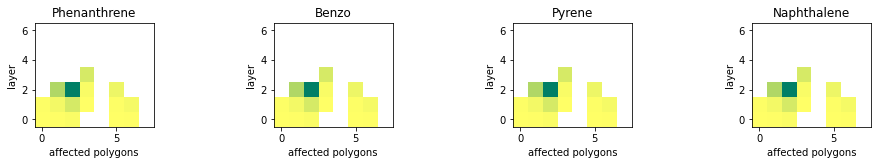

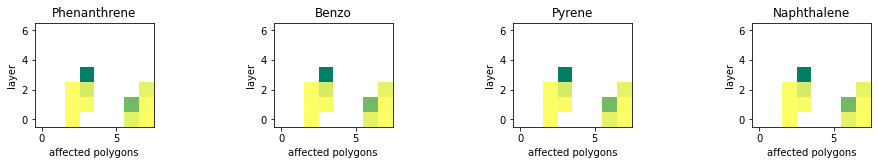

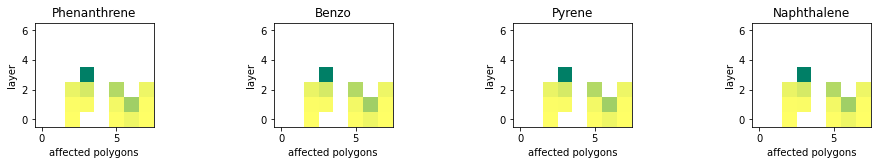

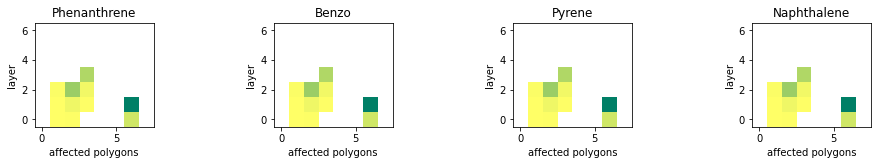

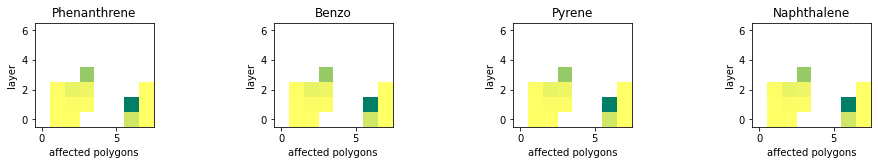

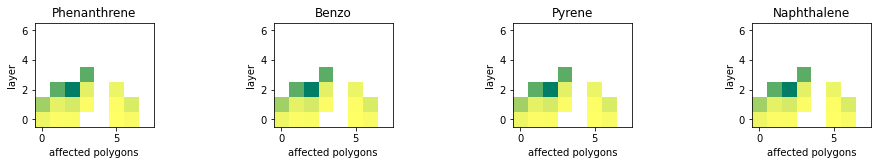

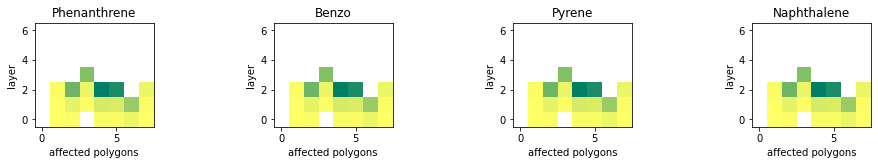

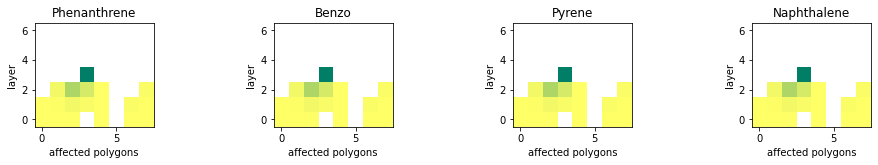

In [33]:
position = 0
for file in oil_files:
    fig = plt.figure(figsize=(20, 18), facecolor='white') #figsize=(9, 12)
    gs = plt.GridSpec(8, 5, wspace=0.5, hspace=0.2, height_ratios=[1,1,1,1,1,1,1,1],)
    for pah in groups.pahs:
        ax = fig.add_subplot(gs[position, list(groups.pahs).index(pah)])
        contam_bl = file.variables[str(pah)][2][affected_boxes_contained][:]
        contam = contam_bl.transpose()
        ax.imshow(contam, cmap=cm.summer_r) #copper_r
        ax.invert_yaxis() 
        ax.set_title(str(pah), fontsize = 12)
        ax.set_ylabel('layer')
        ax.set_xlabel('affected polygons')
    position = position + 1

## Concentration of PCs in seawater

In [3]:
# Read in salish sea atlantis output files.
control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/highres-300d_0contam_v6720/outputSalishSea.nc"
control = xr.open_dataset(str(control_file), decode_cf=True)
time = np.ma.filled(control.variables['t'])

In [4]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/')
scenario_paths = sorted([p for p in scenario_root.glob('highres-300d_5b_1_2019-01-20_WSF_v6722/outputSalishSea.nc')])
for path in scenario_paths:
    print(path.parent.stem, groups.conditions[str(path.parent.stem).split(sep = '_')[3]])

highres-300d_5b_1_2019-01-20_WSF_v6722 low Fraser flow spring tide winter


In [5]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

In [6]:
# time after burn-in
start = 0
end = time.size-1

Half lives

| PAH Concentration	|	Naphthalene |	Phenanthrene | Pyrene |	Benzo(a)pyrene |
|-------------------|---------------|-----------------|--------|----------|
| Half life (secs)	|	259200 |	3628800	| 20476800	| 19353600 |
| Half life (days)	|	3	| 42 |	237 |	224 |

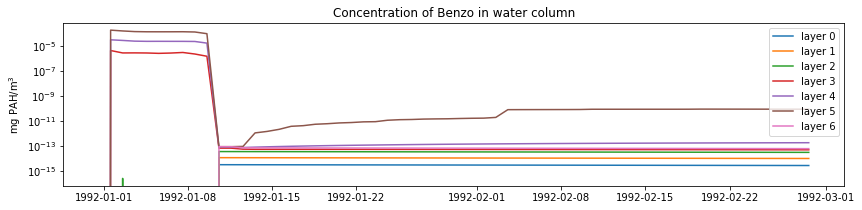

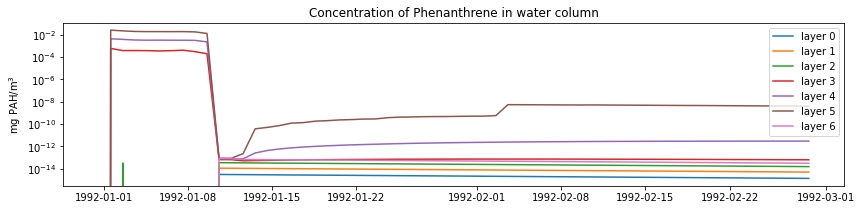

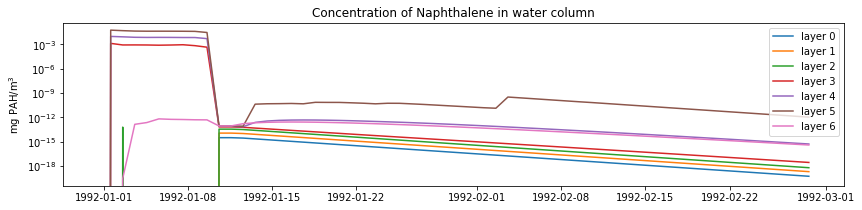

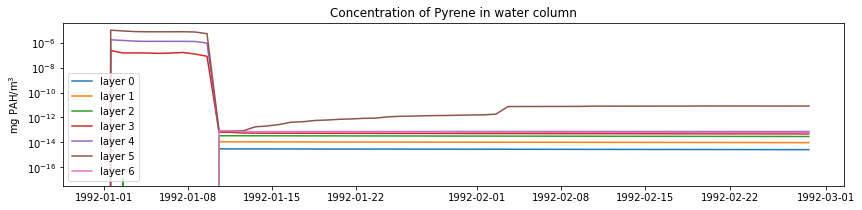

In [11]:
for pah in groups.pahs:
  fig, ax = plt.subplots(figsize = (14,3))
  names = []
  line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))
  for scenario, path, i in zip(scenario_datasets,scenario_paths,range(0,len(scenario_datasets))):
      nm = path.parent.stem.split(sep = '_')
      names.append('TP-'+groups.conditions_with_letters[str(nm[2])])
      contam = scenario.variables[str(pah)][start:end,:,:]
      contam = contam.sum(axis=1)
      ax.semilogy(scenario.t[start:end], contam) #, color=hex_colour, linestyle=next(line_styles))
  ax.set_title('Concentration of '+ pah +' in water column', fontsize = 12)
  ax.set_ylabel('mg PAH/m$^3$')
  ax.legend(['layer 0', 'layer 1', 'layer 2', 'layer 3', 'layer 4', 'layer 5', 'layer 6'])
  #ax.legend(names, loc='best')

## Concentration of PAH in Plankton and Benthos - test for uptake

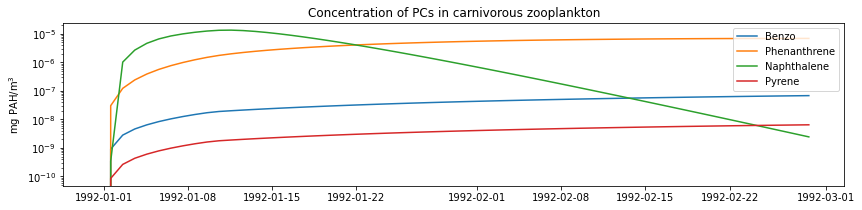

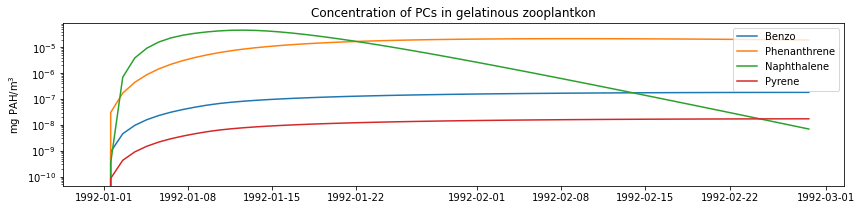

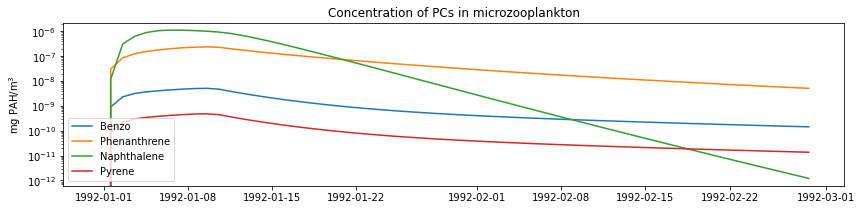

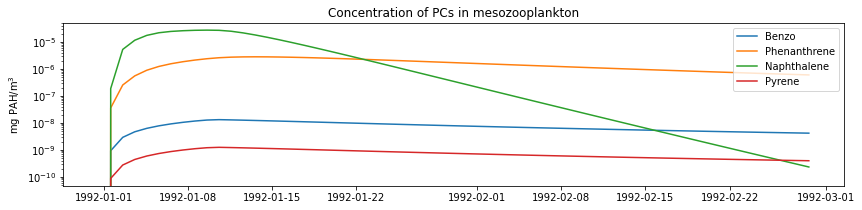

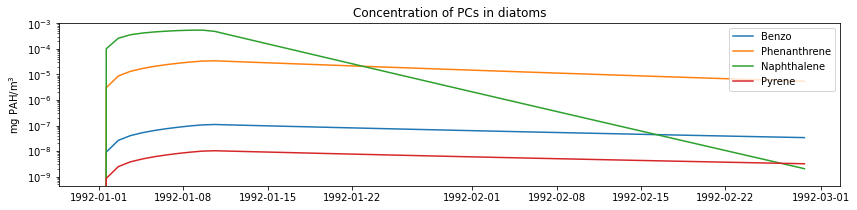

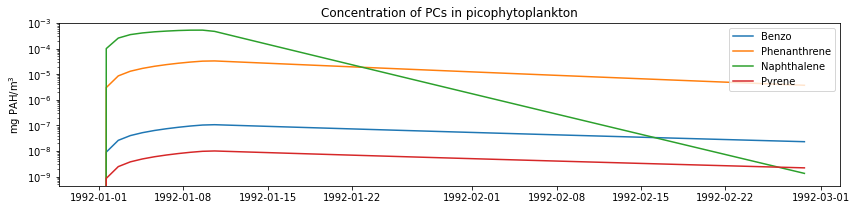

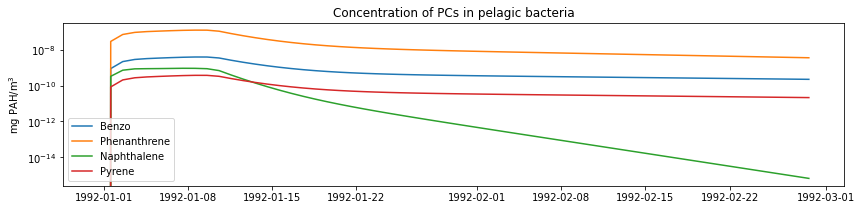

In [16]:
for plankton in groups.plankton:
  fig, ax = plt.subplots(figsize = (14,3))
  names = []
  line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))
  for pah in groups.pahs:
    contam = scenario.variables[str(groups.plankton[plankton])+'_'+str(pah)][start:end,:,:]
    contam = contam.sum(axis=(1,2))
    ax.semilogy(scenario.t[start:end], contam, label=pah) #, color=hex_colour, linestyle=next(line_styles))
  ax.set_title('Concentration of PCs in '+ plankton, fontsize = 12)
  ax.set_ylabel('mg PAH/m$^3$')
  ax.legend()
  #ax.legend(names, loc='best')

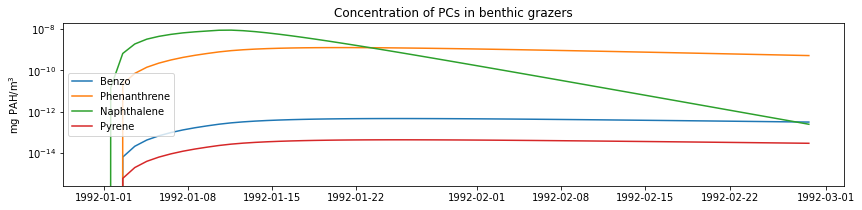

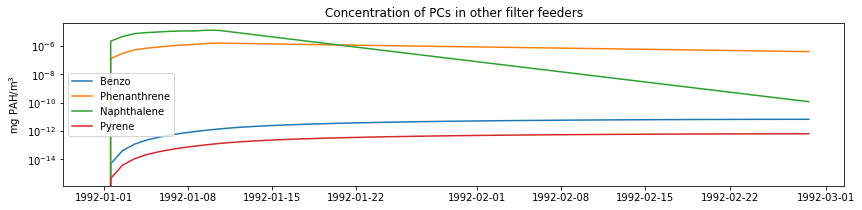

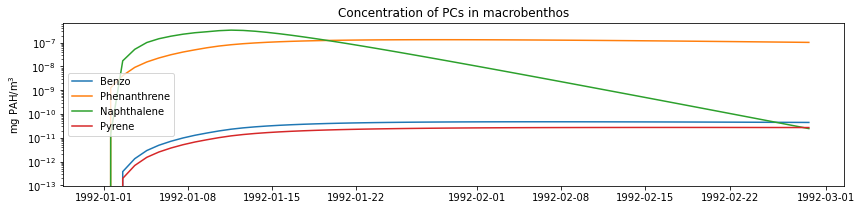

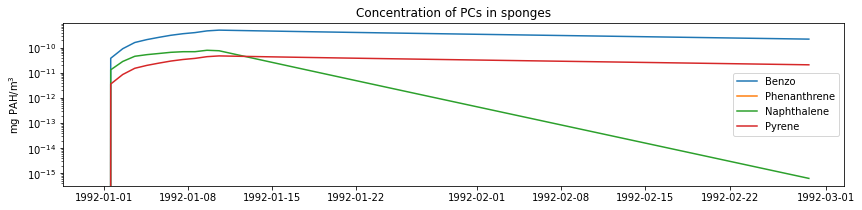

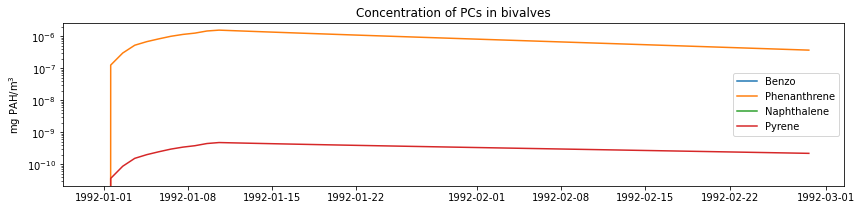

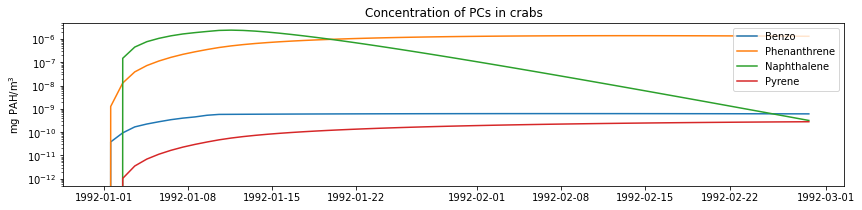

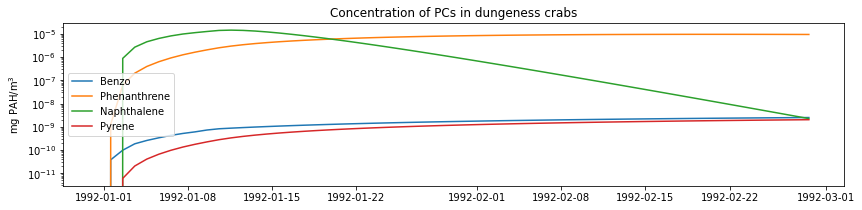

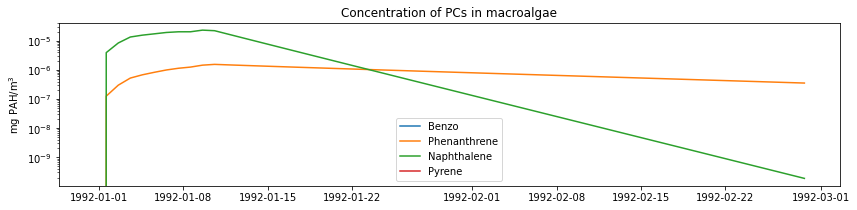

/home/rlovindeer/conda_envs/parcels-dev/lib/python3.8/site-packages/matplotlib_inline/backend_inline.py:234: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  for label in axis.get_ticklabels()])


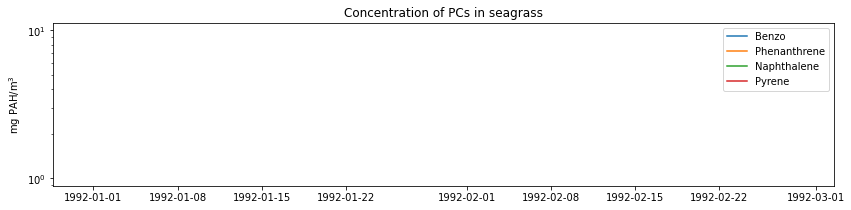

In [17]:
for species in groups.benthos:
  fig, ax = plt.subplots(figsize = (14,3))
  names = []
  line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))
  for pah in groups.pahs:
    contam = scenario.variables[str(groups.benthos[species])+'_'+str(pah)][start:end,:]
    contam = contam.sum(axis=1)
    ax.semilogy(scenario.t[start:end], contam, label=pah) #, color=hex_colour, linestyle=next(line_styles))
  ax.set_title('Concentration of PCs in '+ species, fontsize = 12)
  ax.set_ylabel('mg PAH/m$^3$')
  ax.legend()
  #ax.legend(names, loc='best')

/tmp/ipykernel_1783723/1319723194.py:20: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ylabels = ax.get_yticklabels()


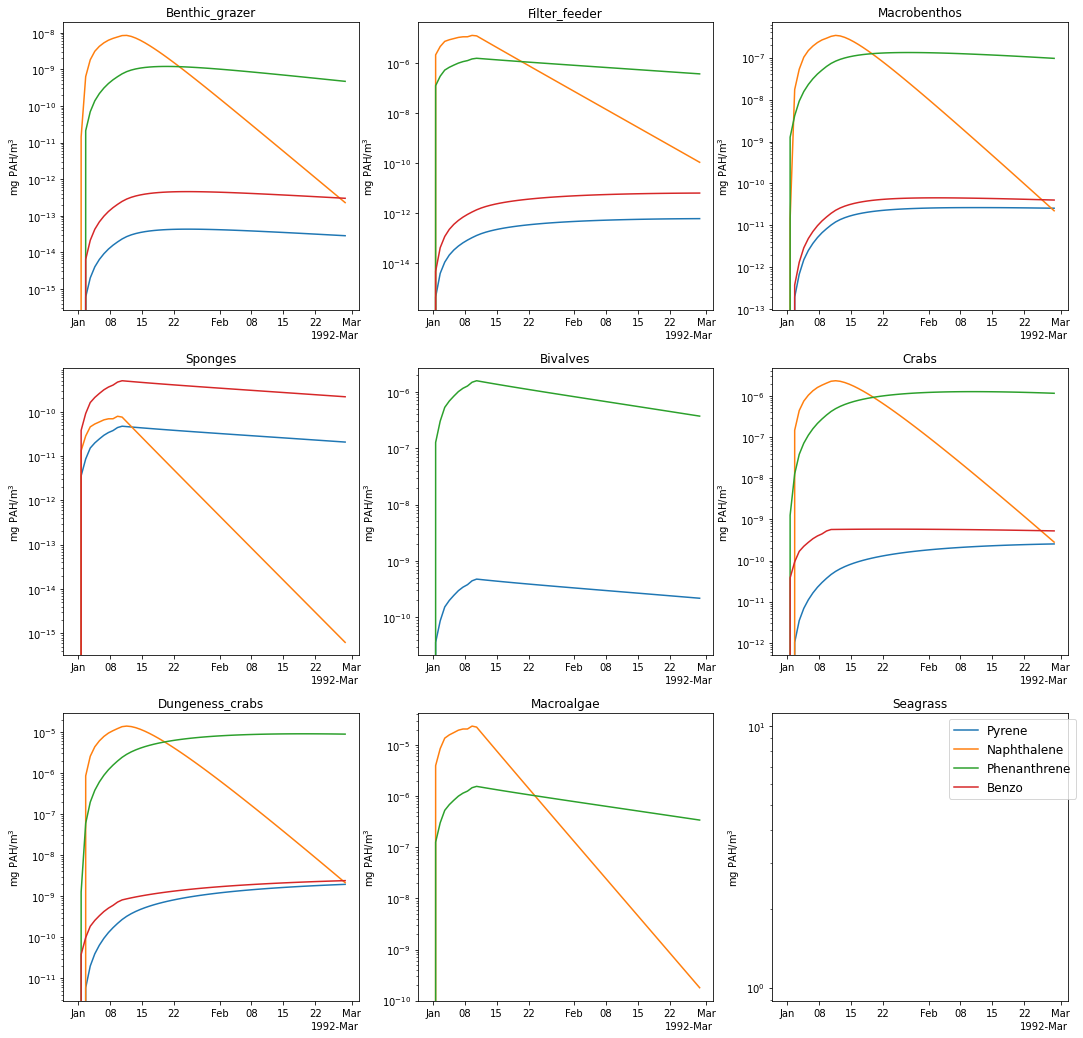

In [13]:
fig = plt.figure(figsize=(18, 18), facecolor='white')
gs = plt.GridSpec(3, 3, wspace=0.2, hspace=0.2, width_ratios=[1, 1, 1], height_ratios=[1, 1, 1])

for scenario in scenario_datasets:
    for species in groups.benthos:
        
        bio_index = (list(groups.benthos).index(species))
        if bio_index < 3:
            position = 0, bio_index
        elif bio_index > 5: 
            position = 2, bio_index-6
        else :
            position = 1, bio_index-3
        ax = fig.add_subplot(gs[position])
        for pah in groups.pahs:
            contam = scenario.variables[str(groups.benthos[species])+'_'+str(pah)][start:end,:]
            contam = contam.sum(axis=1)
            ax.semilogy(scenario.t[start:end], contam, label=pah) #, color=hex_colour, linestyle=next(line_styles))
        ax.set_title(groups.benthos[species], fontsize = 12)
        ylabels = ax.get_yticklabels()
        xlabels = ax.get_xticklabels()
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
        ax.set_ylabel('mg PAH/m$^3$')
        #ax.legend()
    ax.legend(bbox_to_anchor=(1.05, 1), fontsize=12)